In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics

from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler,RobustScaler,OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

import plotly as py
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot, plot
import plotly.express as px

from imblearn.over_sampling import KMeansSMOTE, SMOTE, ADASYN, BorderlineSMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks, EditedNearestNeighbours, RepeatedEditedNearestNeighbours
from imblearn.combine import SMOTEENN, SMOTETomek

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate, StratifiedKFold, train_test_split, GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold, RepeatedKFold, RepeatedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.model_selection import permutation_test_score, StratifiedShuffleSplit

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PowerTransformer

from sklearn.feature_selection import SelectKBest, SelectPercentile, SelectFromModel, RFE, RFECV
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif
from sklearn.feature_selection import f_regression, mutual_info_regression

from collections import Counter

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import (cross_validate, StratifiedKFold, train_test_split,GridSearchCV,
                                    HalvingGridSearchCV)

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

print("Project has been created with this version of Pandas: " ,pd. __version__," And with this version of Numpy: ",np. __version__)

Project has been created with this version of Pandas:  2.2.2  And with this version of Numpy:  1.26.4


In [10]:
df = pd.read_csv('../datasets/processed/heart_no_nans.csv')

In [11]:
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,...,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past 2 years (1 year but less than 2 ye...,No,No,Yes,No,...,"White only, Non-Hispanic",Age 80 or older,1.60,78.02,30.47,No,No,No,No,No
1,Alabama,Female,Very good,0.0,0.0,Within past 2 years (1 year but less than 2 ye...,Yes,Yes,Yes,No,...,"White only, Non-Hispanic",Age 80 or older,1.45,59.87,28.56,No,No,Yes,Yes,No
2,Alabama,Female,Very good,2.0,0.0,Within past 5 years (2 years but less than 5 y...,Yes,No,No,No,...,"White only, Non-Hispanic",Age 75 to 79,1.68,77.11,27.44,No,Yes,Yes,Yes,No
3,Alabama,Female,Fair,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,No,Yes,No,...,"White only, Non-Hispanic",Age 75 to 79,1.73,77.11,25.85,Yes,No,No,Yes,No
4,Alabama,Female,Good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,Yes,Yes,No,...,"Black only, Non-Hispanic",Age 60 to 64,1.57,74.84,30.18,Yes,Yes,No,No,Yes


In [12]:
df.duplicated().sum()

196

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

0

In [15]:
label_encoder = LabelEncoder()

label_columns = ['HighBloodPressure', 'LastCheckupTime', 'HadDiabetes']

for col in label_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [16]:
df = pd.get_dummies(df, columns=['RaceEthnicityCategory', 'Sex'], dtype=int, drop_first=True)

In [17]:
ordinal_mapping = {
    'GeneralHealth': { "Excellent": 5, "Very good": 4, "Good": 3, "Fair": 2, "Poor": 1 },
    'SmokerStatus': { "Current smoker - now smokes every day": 4,
                     "Current smoker - now smokes some days": 3,
                     "Former smoker": 2,
                     "Never smoked": 1 },
    'ECigaretteUsage': { "Never used e-cigarettes in my entire life": 1,
                         "Use them every day": 4,
                         "Use them some days": 3,
                         "Not at all (right now)": 2 },
    'AgeCategory': { "Age 18 to 24": 1, "Age 25 to 29": 2, "Age 30 to 34": 3,
                    "Age 35 to 39": 4, "Age 40 to 44": 5, "Age 45 to 49": 6,
                    "Age 50 to 54": 7, "Age 55 to 59": 8, "Age 60 to 64": 9,
                    "Age 65 to 69": 10, "Age 70 to 74": 11, "Age 75 to 79": 12,
                    "Age 80 or older": 13 }
}

for col, mapping in ordinal_mapping.items():
    df[col] = df[col].map(mapping)

In [18]:
df.replace({'No': 0, 'Yes': 1}, inplace=True)

In [19]:
state_encoding = df.groupby('State')['HadHeartAttack'].mean().to_dict()
df['State'] = df['State'].map(state_encoding)

In [20]:
df.head()

,State,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,HadAngina,...,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic",Sex_Male
0,0.061544,4,0.0,0.0,1,0,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0.061544,4,0.0,0.0,1,1,1,2,0,0,...,0,0,1,1,0,0,0,0,1,0
2,0.061544,4,2.0,0.0,2,1,0,0,0,0,...,0,1,1,1,0,0,0,0,1,0
3,0.061544,2,0.0,0.0,3,1,0,2,0,0,...,1,0,0,1,0,0,0,0,1,0
4,0.061544,3,2.0,3.0,3,1,1,2,0,0,...,1,1,0,0,1,0,0,0,0,0


In [21]:
df.columns

Index(['State', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays',
       'LastCheckupTime', 'PhysicalActivities', 'HighCholesterol',
       'HighBloodPressure', 'HadHeartAttack', 'HadAngina', 'HadStroke',
       'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder',
       'HadKidneyDisease', 'HadArthritis', 'HadDiabetes',
       'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms',
       'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'CovidPos', 'RaceEthnicityCategory_Hispanic',
       'RaceEthnicityCategory_Multiracial, Non-Hispanic',
       'RaceEthnicityCategory_Other race only, Non-Hispanic',
       'RaceEthnicityCategory_White only, Non-Hispanic', 'Sex_Male'],
      dtype='object')

In [ ]:
# Prepare the data
X = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']

In [ ]:
X = sm.add_constant(X)

In [ ]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Menampilkan hasil VIF
vif_data

,Variable,VIF
0,const,4799.970043
1,State,1.041212
2,GeneralHealth,1.722273
3,PhysicalHealthDays,1.599703
4,MentalHealthDays,1.477340
5,LastCheckupTime,1.095698
6,PhysicalActivities,1.199682
7,HighCholesterol,1.171805
8,HighBloodPressure,1.303678
9,HadAngina,1.117766


In [ ]:
# Menstandarisasi data untuk PCA
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['HeightInMeters', 'WeightInKilograms', 'BMI']])

In [ ]:
# Terapkan PCA untuk mereduksi dimensi menjadi 1 komponen utama
pca = PCA(n_components=1)
df['BMI_PCA'] = pca.fit_transform(scaled_features)

# Hapus kolom asli yang sudah digantikan oleh PCA
df.drop(['HeightInMeters', 'WeightInKilograms', 'BMI'], axis=1, inplace=True)

# Menampilkan DataFrame setelah PCA diterapkan
df

,State,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,HadAngina,...,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic",Sex_Male,BMI_PCA
0,0.061544,4,0.0,0.0,1,0,0,2,0,0,...,0,0,0,0,0,0,0,1,0,-0.340856
1,0.061544,4,0.0,0.0,1,1,1,2,0,0,...,0,1,1,0,0,0,0,1,0,-1.605582
2,0.061544,4,2.0,0.0,2,1,0,0,0,0,...,1,1,1,0,0,0,0,1,0,-0.407721
3,0.061544,2,0.0,0.0,3,1,0,2,0,0,...,0,0,1,0,0,0,0,1,0,-0.401465
4,0.061544,3,2.0,3.0,3,1,1,2,0,0,...,1,0,0,1,0,0,0,0,0,-0.569928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257692,0.030075,3,0.0,0.0,3,1,1,2,0,0,...,1,0,0,0,0,0,0,0,0,-0.621836
257693,0.030075,4,0.0,0.0,1,0,0,2,0,0,...,1,0,1,0,0,0,0,0,1,-1.112792
257694,0.030075,4,0.0,0.0,3,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,-1.043247
257695,0.030075,4,10.0,0.0,3,1,1,0,0,0,...,1,1,0,0,1,0,0,0,0,0.908669


In [ ]:
df.head()

,State,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,HighCholesterol,HighBloodPressure,HadHeartAttack,HadAngina,...,HIVTesting,FluVaxLast12,PneumoVaxEver,CovidPos,RaceEthnicityCategory_Hispanic,"RaceEthnicityCategory_Multiracial, Non-Hispanic","RaceEthnicityCategory_Other race only, Non-Hispanic","RaceEthnicityCategory_White only, Non-Hispanic",Sex_Male,BMI_PCA
0,0.061544,4,0.0,0.0,1,0,0,2,0,0,...,0,0,0,0,0,0,0,1,0,-0.340856
1,0.061544,4,0.0,0.0,1,1,1,2,0,0,...,0,1,1,0,0,0,0,1,0,-1.605582
2,0.061544,4,2.0,0.0,2,1,0,0,0,0,...,1,1,1,0,0,0,0,1,0,-0.407721
3,0.061544,2,0.0,0.0,3,1,0,2,0,0,...,0,0,1,0,0,0,0,1,0,-0.401465
4,0.061544,3,2.0,3.0,3,1,1,2,0,0,...,1,0,0,1,0,0,0,0,0,-0.569928


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

In [ ]:
# Inisialisasi model (Logistic Regression sebagai contoh)
model = LogisticRegression(max_iter=10000)

# Inisialisasi RFE untuk memilih fitur terbaik
rfe = RFE(estimator=model, n_features_to_select=10)  # Pilih 10 fitur terbaik

# Fitting RFE
X_train_rfe = rfe.fit_transform(X_train, y_train)

# Menampilkan fitur yang terpilih
selected_features = X_train.columns[rfe.support_]
print("Fitur terpilih: ", selected_features)

Fitur terpilih:  Index(['const', 'GeneralHealth', 'HighCholesterol', 'HadAngina', 'HadStroke',
       'HadCOPD', 'HadKidneyDisease', 'BlindOrVisionDifficulty',
       'AlcoholDrinkers', 'Sex_Male'],
      dtype='object')


In [ ]:
# Evaluasi menggunakan cross-validation
cv_scores = cross_val_score(model, X_train_rfe, y_train, cv=5, scoring='accuracy')
print("Akurasi Cross Validation: ", np.mean(cv_scores))

Akurasi Cross Validation:  0.9470052277819268


In [ ]:
# Train model dengan fitur terpilih
model.fit(X_train_rfe, y_train)

# Transformasi data uji menggunakan fitur yang sama dengan yang terpilih
X_test_rfe = rfe.transform(X_test)

# Prediksi dan evaluasi
y_pred = model.predict(X_test_rfe)

# Evaluasi performa
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Akurasi: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Akurasi: 0.95
Precision: 0.56
Recall: 0.22
F1 Score: 0.31


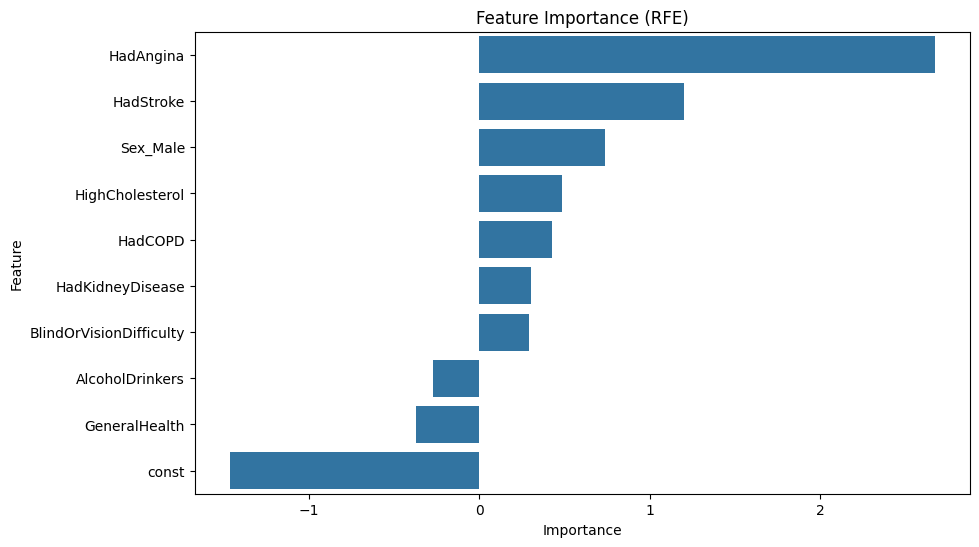

In [ ]:
# Visualisasi fitur terpilih
importances = rfe.estimator_.coef_[0]
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance (RFE)')
plt.show()

In [ ]:
# Use MinMaxScaler (alternative to StandardScaler)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Apply SMOTE for handling class imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

Confusion Matrix:
[[70498 14477]
 [ 1278  3873]]
           Logistic_Regression_KSMOTE
Accuracy                     0.825189
Precision                    0.211063
Recall                       0.751893
F1-score                     0.329603
AUC-PR                       0.395120


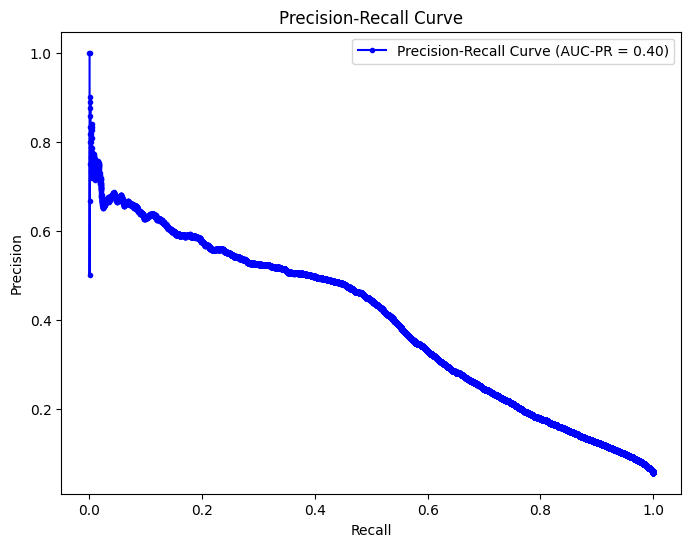

In [ ]:
# Logistic Regression model with class weight
logreg = LogisticRegression(solver='liblinear', penalty='l2', class_weight='balanced', max_iter=10000, random_state=42)

# Hyperparameter tuning with Stratified KFold and GridSearchCV
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10],  # Tuning regularization strength
    'max_iter': [100, 500, 1000, 10000],  # Experiment with different iteration limits
    'penalty': ['l2', 'elasticnet'],  # ElasticNet as an alternative penalty
    'solver': ['liblinear', 'saga']  # Try different solvers, 'saga' can handle elasticnet
}

# StratifiedKFold for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(logreg, param_grid, cv=skf, scoring='accuracy')
grid_search.fit(X_train_smote, y_train_smote)

# Best model from GridSearchCV
best_model = grid_search.best_estimator_

# Step 3: Predict and Evaluate
y_pred_log_k = best_model.predict(X_test_scaled)
y_pred_proba_log_k = best_model.predict_proba(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log_k)
print('Confusion Matrix:')
print(cm)

# Calculate Precision-Recall and AUC-PR
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_log_k[:, 1])
auc_pr = auc(recall, precision)  # AUC for Precision-Recall curve

# Evaluation DataFrame
KSMOTE_log_eval = pd.DataFrame(data=[
    accuracy_score(y_test, y_pred_log_k),
    precision_score(y_test, y_pred_log_k, average='binary'),
    recall_score(y_test, y_pred_log_k, average='binary'),
    f1_score(y_test, y_pred_log_k, average='binary'),
    auc_pr
], index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-PR'],
   columns=["Logistic_Regression_KSMOTE"])

# Display evaluation results
print(KSMOTE_log_eval)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', color='b', label="Precision-Recall Curve (AUC-PR = %0.2f)" % auc_pr)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [ ]:
# # Apply ADASYN for handling class imbalance
# adasyn = ADASYN(sampling_strategy='auto', random_state=42)
# X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train)

# # Visualize the distribution after ADASYN
# plt.figure(figsize=(10, 6))
# ax = sns.countplot(x=y_train_adasyn, palette='Set2')
# for container in ax.containers:
#     ax.bar_label(container, label_type='center', rotation=0, color='white')
# plt.title("Distribution After ADASYN", size=14)
# plt.show()

# # Logistic Regression model with class weight
# logreg = LogisticRegression(solver='liblinear', penalty='l2', class_weight='balanced', max_iter=10000, random_state=42)

# # Hyperparameter tuning with Stratified KFold and GridSearchCV
# param_grid = {
#     'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Tuning regularization strength
#     'max_iter': [100, 500, 1000, 10000],  # Experiment with different iteration limits
#     'penalty': ['l2', 'elasticnet'],  # ElasticNet as an alternative penalty
#     'solver': ['liblinear', 'saga']  # Try different solvers, 'saga' can handle elasticnet
# }

# # StratifiedKFold for cross-validation
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # GridSearchCV
# grid_search = GridSearchCV(logreg, param_grid, cv=skf, scoring='accuracy')
# grid_search.fit(X_train_adasyn, y_train_adasyn)

# # Best model from GridSearchCV
# best_model = grid_search.best_estimator_

# # Step 3: Predict and Evaluate
# y_pred_log_k = best_model.predict(X_test_scaled)
# y_pred_proba_log_k = best_model.predict_proba(X_test_scaled)

# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred_log_k)
# print('Confusion Matrix:')
# print(cm)

# # Calculate Precision-Recall and AUC-PR
# precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_log_k[:, 1])
# auc_pr = auc(recall, precision)  # AUC for Precision-Recall curve

# # Calculate ROC-AUC
# roc_auc = roc_auc_score(y_test, y_pred_proba_log_k[:, 1])
# print("ROC-AUC:", roc_auc)

# # Evaluation DataFrame
# log_eval = pd.DataFrame(data=[
#     accuracy_score(y_test, y_pred_log_k),
#     precision_score(y_test, y_pred_log_k, average='binary'),
#     recall_score(y_test, y_pred_log_k, average='binary'),
#     f1_score(y_test, y_pred_log_k, average='binary'),
#     auc_pr,
#     roc_auc
# ], index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-PR', 'AUC-ROC'],
#    columns=["Logistic_Regression_ADASYN"])

# # Display evaluation results
# print(log_eval)

# # Plot Precision-Recall Curve
# plt.figure(figsize=(8, 6))
# plt.plot(recall, precision, marker='.', color='b', label="Precision-Recall Curve (AUC-PR = %0.2f)" % auc_pr)
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend()
# plt.show()

# # Plot ROC Curve
# fpr, tpr, _ = roc_curve(y_test, y_pred_proba_log_k[:, 1])
# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, color='b', label="ROC Curve (AUC-ROC = %0.2f)" % roc_auc)
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')
# plt.legend()
# plt.show()

In [ ]:
# # Apply ADASYN for handling class imbalance
# adasyn = ADASYN(sampling_strategy='auto', random_state=42)
# X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train)

# # Visualize the distribution after ADASYN
# plt.figure(figsize=(10, 6))
# ax = sns.countplot(x=y_train_adasyn, palette='Set2')
# for container in ax.containers:
#     ax.bar_label(container, label_type='center', rotation=0, color='white')
# plt.title("Distribution After ADASYN", size=14)
# plt.show()

# # Define Models
# logreg = LogisticRegression(solver='liblinear', penalty='l2', class_weight='balanced', max_iter=10000, random_state=42)
# rf = RandomForestClassifier(n_estimators=100, random_state=42)
# gb = GradientBoostingClassifier(random_state=42)

# # Ensemble Model using Voting Classifier
# voting_clf = VotingClassifier(estimators=[('logreg', logreg), ('rf', rf), ('gb', gb)], voting='soft')

# # Hyperparameter tuning with Stratified KFold and GridSearchCV
# param_grid = {
#     'voting_clf__logreg__C': [0.001, 0.01, 0.1, 1, 10],  # Tuning regularization strength
#     'voting_clf__logreg__max_iter': [100, 500, 1000],  # Experiment with different iteration limits
#     'voting_clf__rf__n_estimators': [100, 200, 300],  # Random forest parameter tuning
#     'voting_clf__gb__n_estimators': [100, 200, 300],  # Gradient boosting parameter tuning
# }

# # StratifiedKFold for cross-validation
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # GridSearchCV
# grid_search = GridSearchCV(voting_clf, param_grid, cv=skf, scoring='accuracy', verbose=1, n_jobs=-1)
# grid_search.fit(X_train_adasyn, y_train_adasyn)

# # Best model from GridSearchCV
# best_model = grid_search.best_estimator_

# # Step 3: Predict and Evaluate
# y_pred_log_k = best_model.predict(X_test_scaled)
# y_pred_proba_log_k = best_model.predict_proba(X_test_scaled)

# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred_log_k)
# print('Confusion Matrix:')
# print(cm)

# # Calculate Precision-Recall and AUC-PR
# precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_log_k[:, 1])
# auc_pr = auc(recall, precision)  # AUC for Precision-Recall curve

# # Calculate ROC-AUC
# roc_auc = roc_auc_score(y_test, y_pred_proba_log_k[:, 1])
# print("ROC-AUC:", roc_auc)

# # Evaluation DataFrame
# log_eval = pd.DataFrame(data=[
#     accuracy_score(y_test, y_pred_log_k),
#     precision_score(y_test, y_pred_log_k, average='binary'),
#     recall_score(y_test, y_pred_log_k, average='binary'),
#     f1_score(y_test, y_pred_log_k, average='binary'),
#     auc_pr,
#     roc_auc
# ], index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-PR', 'AUC-ROC'],
#    columns=["Voting_Classifier"])

# # Display evaluation results
# print(log_eval)

# # Plot Precision-Recall Curve
# plt.figure(figsize=(8, 6))
# plt.plot(recall, precision, marker='.', color='b', label="Precision-Recall Curve (AUC-PR = %0.2f)" % auc_pr)
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend()
# plt.show()

# # Plot ROC Curve
# fpr, tpr, _ = roc_curve(y_test, y_pred_proba_log_k[:, 1])
# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, color='b', label="ROC Curve (AUC-ROC = %0.2f)" % roc_auc)
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')
# plt.legend()
# plt.show()